In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("../data/ABNCleanexcel_data.xlsx")

In [4]:
df = df[[
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "room_type",
    "city"
]]

In [5]:
df.fillna(0, inplace=True)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type,city
0,202,2,383,2.31,1,128,Entire home/apt,San Francisco
1,235,30,111,0.66,1,365,Entire home/apt,San Francisco
2,56,32,9,0.09,13,365,Private room,San Francisco
3,575,9,28,0.17,2,365,Entire home/apt,San Francisco
4,110,1,770,4.65,2,159,Private room,San Francisco
...,...,...,...,...,...,...,...,...
229801,389,2,0,1.00,1,365,Entire home/apt,San Mateo County
229802,158,1,0,1.00,1,364,Entire home/apt,San Mateo County
229803,97,1,0,1.00,32,359,Entire home/apt,San Mateo County
229804,62,2,0,1.00,3,67,Private room,San Mateo County


In [6]:
# Encode Categorical Columns
le = LabelEncoder()

df["room_type"] = le.fit_transform(df["room_type"])
df["city"] = le.fit_transform(df["city"])

In [7]:
# Split X and y
X = df.drop("price", axis=1)

y = df["price"]

In [8]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)


In [10]:
#Evaluate
print("MAE :", mean_absolute_error(y_test,pred_lr))

print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2 :", r2_score(y_test,pred_lr))

MAE : 125.48089295561046
RMSE : 213.56438913774886
R2 : 0.08977504403846415


In [11]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [12]:
# Evaluate Random Forest
print("MAE :", mean_absolute_error(y_test,pred_rf))

print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2 :", r2_score(y_test,pred_rf))

MAE : 106.31310158930287
RMSE : 189.0121390227125
R2 : 0.287031312257062


In [14]:
# Feature Importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                          Feature  Importance
4                availability_365    0.234155
3  calculated_host_listings_count    0.185353
2               reviews_per_month    0.173955
1               number_of_reviews    0.124951
6                            city    0.113558
0                  minimum_nights    0.092116
5                       room_type    0.075912


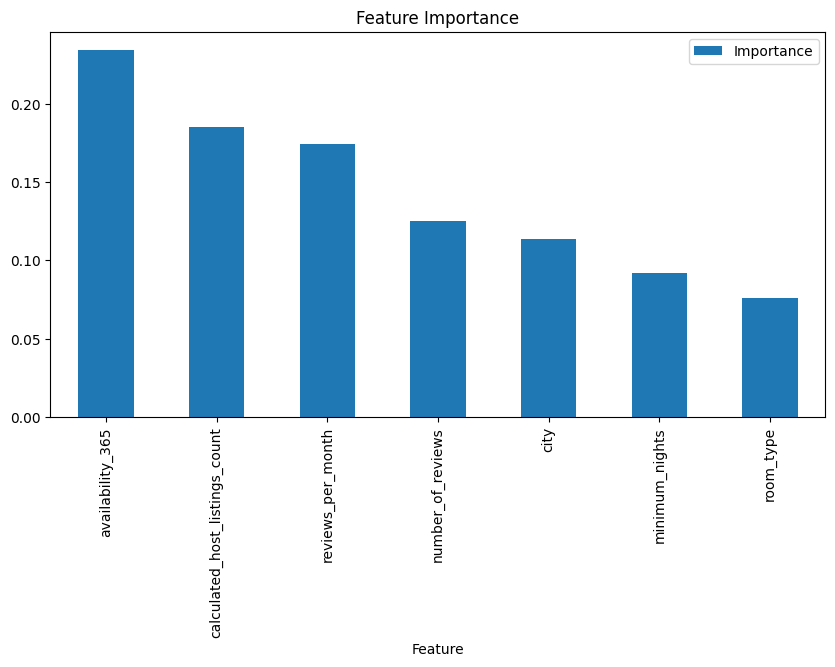

In [15]:
# Plot Feature Importance
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.show()